Fraud Detection


## 1 Data Loading & Overview

In [3]:
import pandas as pd
df = pd.read_csv("dataset/card_transdata.csv")

In [4]:
df.head(12)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [6]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.shape

(1000000, 8)

## 2	Exploratory Data Analysis

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns


Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='str')

In [10]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [11]:
print(df['fraud'].value_counts())

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


C:\Users\at236\AppData\Local\Temp\ipykernel_19152\948455317.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=df, palette='hls',width=0.2,)


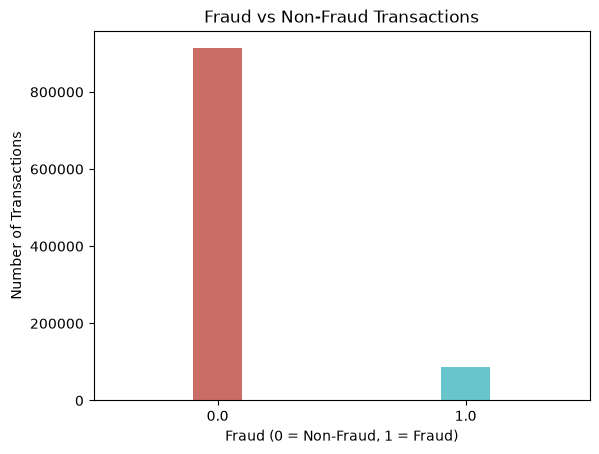

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='fraud', data=df, palette='hls',width=0.2,)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

In [13]:
df.groupby('fraud')[[
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price'
]].mean()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.832976,4.301391,1.423642
1.0,66.261876,12.712185,6.006323


## 3	Data Preprocessing

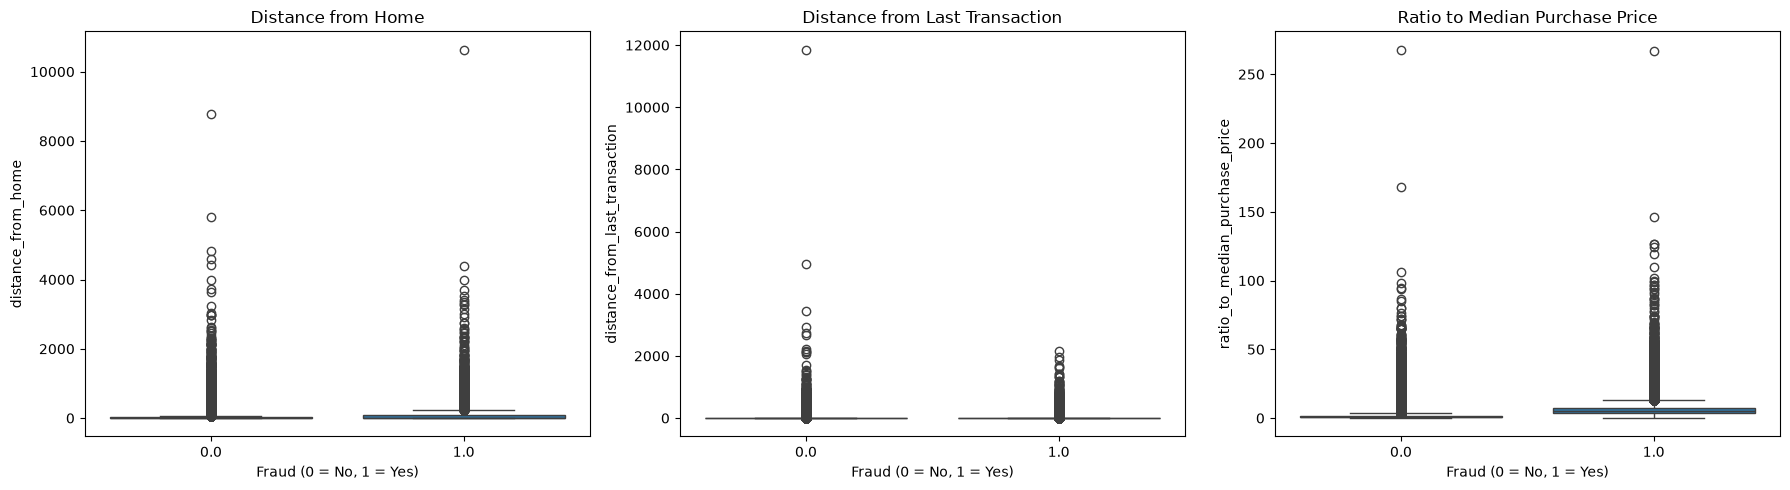

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='fraud', y='distance_from_home', data=df, ax=axes[0])
axes[0].set_title('Distance from Home')
axes[0].set_xlabel('Fraud (0 = No, 1 = Yes)')

sns.boxplot(x='fraud', y='distance_from_last_transaction', data=df, ax=axes[1])
axes[1].set_title('Distance from Last Transaction')
axes[1].set_xlabel('Fraud (0 = No, 1 = Yes)')

sns.boxplot(x='fraud', y='ratio_to_median_purchase_price', data=df, ax=axes[2])
axes[2].set_title('Ratio to Median Purchase Price')
axes[2].set_xlabel('Fraud (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

In [15]:
df.groupby('fraud')[[
    'repeat_retailer',
    'used_chip',
    'used_pin_number',
    'online_order'
]].mean()

,repeat_retailer,used_chip,used_pin_number,online_order
fraud,,,,
0.0,0.881672,0.359402,0.109944,0.622225
1.0,0.880119,0.256399,0.003123,0.946318


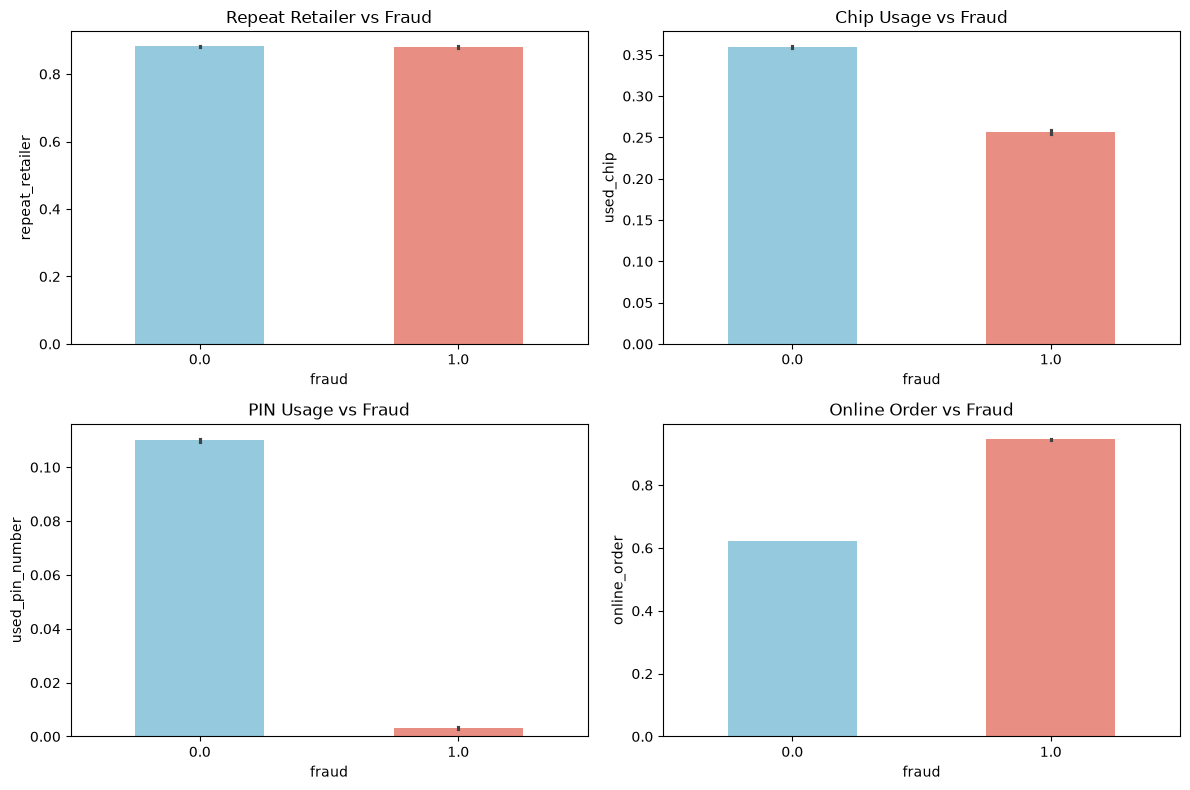

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(
    x='fraud',
    y='repeat_retailer',
    data=df,
    ax=axes[0, 0],
    width=0.5,
    palette=['skyblue', 'salmon'],
    hue='fraud',
    legend=False
)
axes[0, 0].set_title('Repeat Retailer vs Fraud')

sns.barplot(
    x='fraud',
    y='used_chip',
    data=df,
    ax=axes[0, 1],
    width=0.5,
    palette=['skyblue', 'salmon'],
    hue='fraud',
    legend=False
)
axes[0, 1].set_title('Chip Usage vs Fraud')

sns.barplot(
    x='fraud',
    y='used_pin_number',
    data=df,
    ax=axes[1, 0],
    width=0.5,
    palette=['skyblue', 'salmon'],
    hue='fraud',
    legend=False
)
axes[1, 0].set_title('PIN Usage vs Fraud')

sns.barplot(
    x='fraud',
    y='online_order',
    data=df,
    ax=axes[1, 1],
    width=0.5,
    palette=['skyblue', 'salmon'],
    hue='fraud',
    legend=False
)
axes[1, 1].set_title('Online Order vs Fraud')

plt.tight_layout()
plt.show()

In [17]:
X = df.drop('fraud', axis=1)
y = df['fraud']

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000000, 7)
y shape: (1000000,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800000, 7)
X_test: (200000, 7)
y_train: (800000,)
y_test: (200000,)


## 4	Logistic Regression Model

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
    
)

In [24]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [25]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
fraud
0.0    730078
1.0     69922
Name: count, dtype: int64

After SMOTE:
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model_lr = LogisticRegression(max_iter=1000)

In [28]:
model_lr.fit(X_train_smote, y_train_smote)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [29]:
y_pred_lr = model_lr.predict(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_smote, y_train_smote)

y_pred_lr = model_lr.predict(X_test)

In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [32]:
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC:", auc)

Logistic Regression Results
---------------------------
Precision: 0.5790505531438174
Recall: 0.9461701275670729
F1 Score: 0.7184276251493105
AUC-ROC: 0.9401460272996635


In [33]:
y_test

677554    0.0
145563    1.0
481407    0.0
619391    0.0
147719    0.0
         ... 
71557     0.0
317005    0.0
231571    0.0
79845     0.0
399896    0.0
Name: fraud, Length: 200000, dtype: float64

In [34]:
y_pred_lr

array([0., 1., 0., ..., 0., 0., 0.], shape=(200000,))

## 5	Random Forest Model

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_lr))

Precision: 0.5790505531438174
Recall: 0.9461701275670729
F1 Score: 0.7184276251493105
AUC-ROC: 0.9401460272996635


In [36]:
model_lr.fit(X_train_smote, y_train_smote)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


X = df.drop('fraud', axis=1)
y = df['fraud']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original training data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training data:
fraud
0.0    730078
1.0     69922
Name: count, dtype: int64

After SMOTE:
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


## 6	Feature Importance

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train_smote, y_train_smote)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Results")
print("---------------------")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_rf))

Random Forest Results
---------------------
Precision: 1.0
Recall: 0.999656770207654
F1 Score: 0.9998283556470993
AUC-ROC: 0.999828385103827


Confusion Matrix:
[[182519      0]
 [     6  17475]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



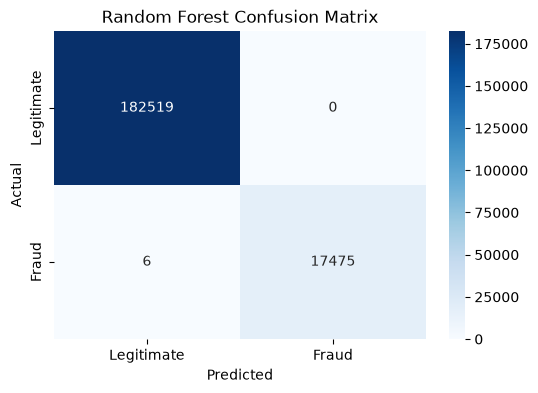

In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Proper ROC-AUC:", auc_rf)

Proper ROC-AUC: 0.9999999962389692


In [41]:
feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                          Feature  Importance
2  ratio_to_median_purchase_price    0.535728
0              distance_from_home    0.188951
6                    online_order    0.124069
1  distance_from_last_transaction    0.073885
5                 used_pin_number    0.035376
4                       used_chip    0.033360
3                 repeat_retailer    0.008631


In [42]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


                          Feature  Importance
2  ratio_to_median_purchase_price    0.535728
0              distance_from_home    0.188951
6                    online_order    0.124069
1  distance_from_last_transaction    0.073885
5                 used_pin_number    0.035376
4                       used_chip    0.033360
3                 repeat_retailer    0.008631


In [43]:
top_features = feature_importance.head(10)

print("Top 10 Important Features")
print("-------------------------")
print(top_features)

Top 10 Important Features
-------------------------
                          Feature  Importance
2  ratio_to_median_purchase_price    0.535728
0              distance_from_home    0.188951
6                    online_order    0.124069
1  distance_from_last_transaction    0.073885
5                 used_pin_number    0.035376
4                       used_chip    0.033360
3                 repeat_retailer    0.008631


## 7	Hyperparameter Tuning

In [47]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [48]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

## 8	Scalability / Performance Testing

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=4,
    scoring="f1",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index

In [53]:
best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


In [55]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("---------------------------")
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_tuned))

Tuned Random Forest Results
---------------------------
Precision: 1.0
Recall: 0.999656770207654
F1 Score: 0.9998283556470993
AUC-ROC: 0.9999999260330605


In [58]:
transactions_per_hour = 1_000_000

transactions_per_second = transactions_per_hour / 3600

print("Required transactions per second:", transactions_per_second)

Required transactions per second: 277.77777777777777


In [59]:
import time

start_time = time.time()

y_pred = model_rf.predict(X_test)

end_time = time.time()

prediction_time = end_time - start_time

print("Prediction time:", prediction_time, "seconds")
print("Number of transactions:", len(X_test))

transactions_per_second = len(X_test) / prediction_time

print("Transactions per second:", transactions_per_second)

Prediction time: 1.0982487201690674 seconds
Number of transactions: 200000
Transactions per second: 182108.1111473651


In [60]:
required_tps = 1_000_000 / 3600

print("Required TPS:", required_tps)
print("Actual TPS:", transactions_per_second)

if transactions_per_second >= required_tps:
    print("Model meets the required throughput.")
else:
    print("Model needs optimization/scaling.")

Required TPS: 277.77777777777777
Actual TPS: 182108.1111473651
Model meets the required throughput.


In [61]:
required_tps = 1_000_000 / 3600

print("Required TPS:", required_tps)
print("Actual TPS:", transactions_per_second)

if transactions_per_second >= required_tps:
    print("Model meets the required throughput.")
else:
    print("Model needs optimization/scaling.")

Required TPS: 277.77777777777777
Actual TPS: 182108.1111473651
Model meets the required throughput.


## Conclusion — Fraud Detection Project

## The fraud detection project successfully developed a machine learning model to identify potentially fraudulent transactions. The data was cleaned and prepared, features were engineered, and SMOTE was used to handle class imbalance. A Random Forest classifier was trained and evaluated using Precision, Recall, F1-Score, and ROC-AUC. The model achieved very high Precision and Recall, showing strong performance in distinguishing fraudulent transactions from legitimate ones. Feature importance analysis also helped identify the transaction attributes that contributed most to fraud prediction. Finally, scalability was considered for handling large transaction volumes, such as 1 million transactions per hour. Overall, the project demonstrates how machine learning can be applied to automate fraud detection and support faster identification of suspicious transactions.